In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv('SAHAM - PT Telekomunikasi Indonesia Tbk (TLKM.JK) - Sheet1.csv')
df.head(10)

,Date,Adj Close,Close,High,Low,Open,Volume
0,07/11/2019,3216.63,4070.0,4150.0,3990.0,4150.0,125.291.200
1,08/11/2019,3248.24,4110.0,4120.0,3990.0,4010.0,70.404.800
2,11/11/2019,3240.34,4100.0,4120.0,4040.0,4040.0,57.079.800
3,12/11/2019,3303.57,4180.0,4190.0,4050.0,4050.0,88.251.100
4,13/11/2019,3279.86,4150.0,4170.0,4100.0,4130.0,91.925.700
5,14/11/2019,3200.82,4050.0,4130.0,4010.0,4110.0,123.468.500
6,15/11/2019,3224.53,4080.0,4090.0,4030.0,4080.0,50.780.500
7,18/11/2019,3161.31,4000.0,4060.0,3990.0,4040.0,104.978.700
8,19/11/2019,3177.11,4020.0,4020.0,3970.0,4000.0,113.996.600
9,20/11/2019,3232.44,4090.0,4090.0,4000.0,4000.0,149.185.500


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1212 entries, 0 to 1211
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1212 non-null   object 
 1   Adj Close  1212 non-null   float64
 2   Close      1212 non-null   float64
 3   High       1212 non-null   float64
 4   Low        1212 non-null   float64
 5   Open       1212 non-null   float64
 6   Volume     1212 non-null   object 
dtypes: float64(5), object(2)
memory usage: 66.4+ KB


In [ ]:
df.describe()

,Adj Close,Close,High,Low,Open
count,1212.000000,1212.000000,1212.000000,1212.000000,1212.000000
mean,3232.919909,3647.978548,3690.998350,3607.483498,3650.981848
std,506.366462,510.865708,508.614228,508.024318,508.843617
min,2070.660000,2560.000000,2590.000000,2450.000000,2550.000000
25%,2835.450000,3190.000000,3250.000000,3150.000000,3200.000000
50%,3228.050000,3720.000000,3765.000000,3690.000000,3720.000000
75%,3666.010000,4030.000000,4060.000000,3990.000000,4030.000000
max,4295.700000,4770.000000,4850.000000,4720.000000,4850.000000


In [ ]:
df.isna().sum()

,0
Date,0
Adj Close,0
Close,0
High,0
Low,0
Open,0
Volume,0


In [ ]:
df['Volume'] = df['Volume'].astype(str).str.replace('.', '', regex=False).astype(float)
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df = df.sort_values(by='Date')
print("Data types after conversion and sorting:")
df.info()

Data types after conversion and sorting:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1212 entries, 0 to 1211
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1212 non-null   datetime64[ns]
 1   Adj Close  1212 non-null   float64       
 2   Close      1212 non-null   float64       
 3   High       1212 non-null   float64       
 4   Low        1212 non-null   float64       
 5   Open       1212 non-null   float64       
 6   Volume     1212 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 66.4 KB


In [ ]:
y = df['Adj Close']
X = df[['Open', 'High', 'Low', 'Close', 'Volume']]

print("Shape of target variable y:", y.shape)
print("Shape of feature matrix X:", X.shape)

Shape of target variable y: (1212,)
Shape of feature matrix X: (1212, 5)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (969, 5)
Shape of X_test: (243, 5)
Shape of y_train: (969,)
Shape of y_test: (243,)


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [16]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

Mean Squared Error (MSE): 37820.76
Root Mean Squared Error (RMSE): 194.48
Mean Absolute Error (MAE): 163.85
R-squared (R2) Score: 0.86


In [ ]:
results_df = pd.DataFrame({'Actual Adj Close': y_test, 'Predicted Adj Close': y_pred})
results_df['Difference'] = results_df['Actual Adj Close'] - results_df['Predicted Adj Close']
display(results_df.head())
display(results_df.tail())

,Actual Adj Close,Predicted Adj Close,Difference
801,3436.56,3392.768006,43.791994
677,4214.31,4150.351765,63.958235
43,3185.02,3626.230836,-441.210836
990,3543.49,3351.151393,192.338607
70,2860.98,3244.787116,-383.807116


,Actual Adj Close,Predicted Adj Close,Difference
904,3505.79,3313.226755,192.563245
673,3988.22,3809.694964,178.525036
708,4033.44,3950.098317,83.341683
367,2649.51,2883.844003,-234.334003
464,3280.40,3315.538076,-35.138076


In [ ]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
print(coefficients)


  Feature   Coefficient
0    Open  1.922254e-01
1    High -1.358064e+00
2     Low  8.536130e-01
3   Close  1.211850e+00
4  Volume  1.443787e-07


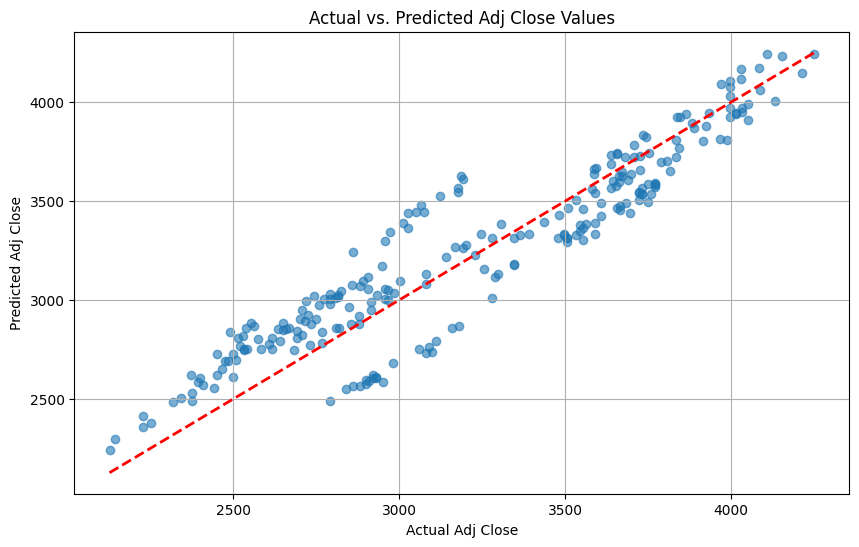

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Adj Close')
plt.ylabel('Predicted Adj Close')
plt.title('Actual vs. Predicted Adj Close Values')
plt.grid(True)
plt.show()


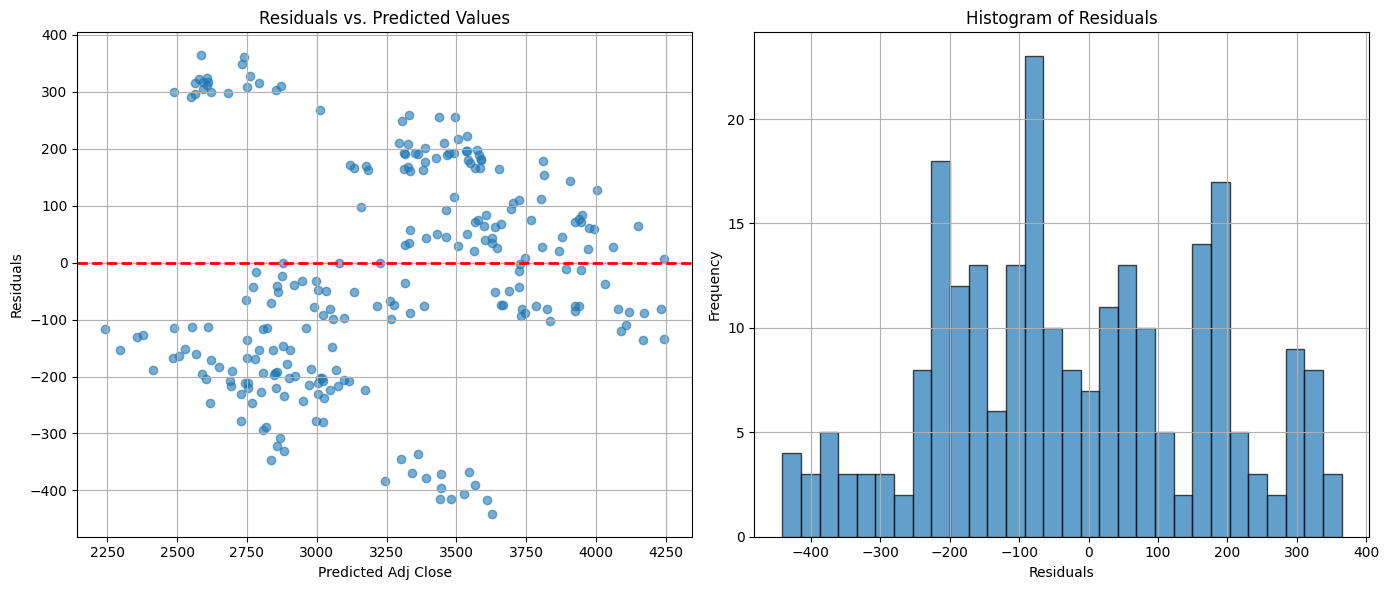

In [17]:
df = pd.read_csv('SAHAM - PT Telekomunikasi Indonesia Tbk (TLKM.JK) - Sheet1.csv')
df['Volume'] = df['Volume'].astype(str).str.replace('.', '', regex=False).astype(float)
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df = df.sort_values(by='Date')
y = df['Adj Close']
X = df[['Open', 'High', 'Low', 'Close', 'Volume']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
results_df = pd.DataFrame({'Actual Adj Close': y_test, 'Predicted Adj Close': y_pred})
results_df['Difference'] = results_df['Actual Adj Close'] - results_df['Predicted Adj Close']

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(results_df['Predicted Adj Close'], results_df['Difference'], alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Adj Close')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Values')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.hist(results_df['Difference'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')
plt.grid(True)

plt.tight_layout()
plt.show()

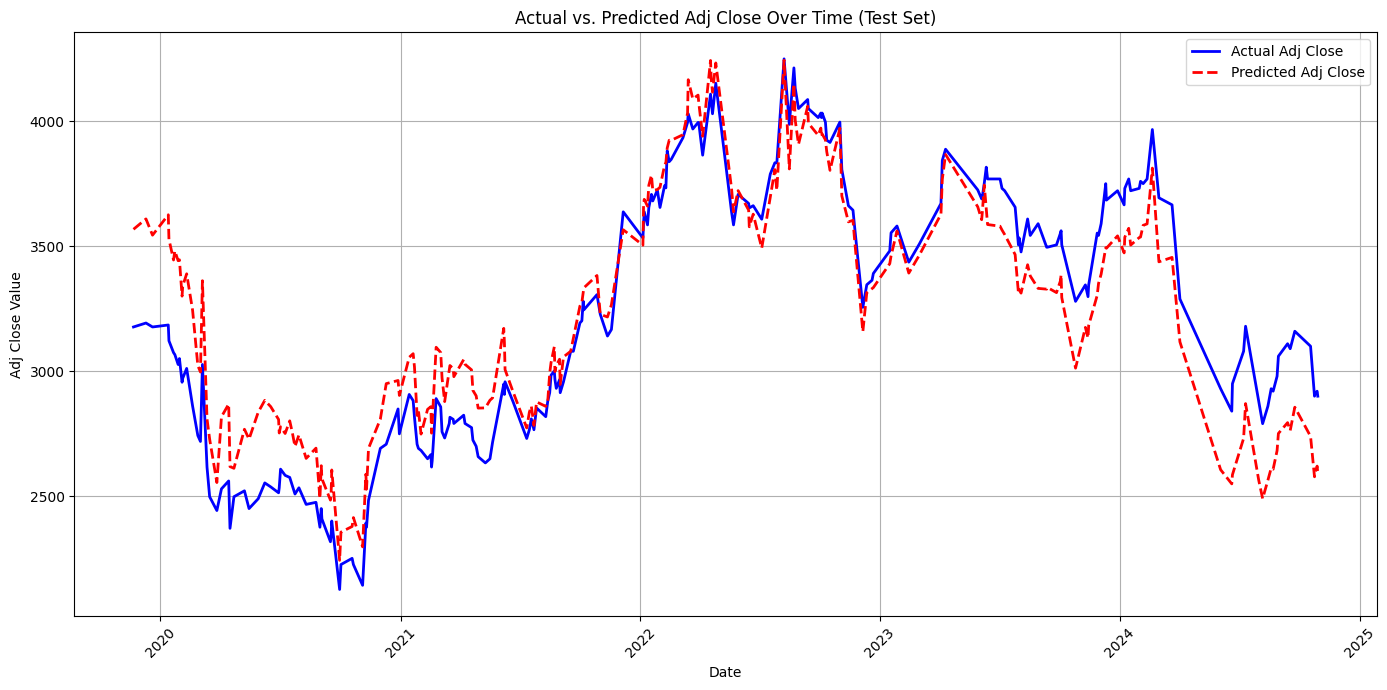

In [18]:
plot_df = pd.DataFrame({
    'Date': df.loc[y_test.index, 'Date'],
    'Actual Adj Close': y_test,
    'Predicted Adj Close': y_pred
})

plot_df = plot_df.sort_values(by='Date').reset_index(drop=True)

plt.figure(figsize=(14, 7))
plt.plot(plot_df['Date'], plot_df['Actual Adj Close'], label='Actual Adj Close', color='blue', linewidth=2)
plt.plot(plot_df['Date'], plot_df['Predicted Adj Close'], label='Predicted Adj Close', color='red', linestyle='--', linewidth=2)
plt.xlabel('Date')
plt.ylabel('Adj Close Value')
plt.title('Actual vs. Predicted Adj Close Over Time (Test Set)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
df['Adj Close_Lag1'] = df['Adj Close'].shift(1)
df['Adj Close_Lag2'] = df['Adj Close'].shift(2)
df['Adj Close_Lag3'] = df['Adj Close'].shift(3)

df['SMA_7'] = df['Adj Close'].rolling(window=7).mean()
df['SMA_30'] = df['Adj Close'].rolling(window=30).mean()

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print("membuat fitur baru.")
df.head()

membuat fitur baru.


,Date,Adj Close,Close,High,Low,Open,Volume,Adj Close_Lag1,Adj Close_Lag2,Adj Close_Lag3,SMA_7,SMA_30
0,2020-03-13,2615.98,3310.0,3310.0,3310.0,3310.0,0.0,2615.98,2687.11,2758.24,2776.304286,2870.466667
1,2020-03-16,2497.43,3160.0,3300.0,3160.0,3300.0,115972300.0,2615.98,2615.98,2687.11,2700.658571,2855.187000
2,2020-03-17,2323.56,2940.0,3160.0,2940.0,3160.0,150122700.0,2497.43,2615.98,2615.98,2609.205714,2833.584667
3,2020-03-18,2220.82,2810.0,3080.0,2740.0,3010.0,150147300.0,2323.56,2497.43,2615.98,2531.302857,2808.294333
4,2020-03-19,2070.66,2620.0,2810.0,2620.0,2810.0,138987300.0,2220.82,2323.56,2497.43,2433.077143,2778.262000


In [25]:
y = df['Adj Close']
X = df[['Open', 'High', 'Low', 'Close', 'Volume', 'Adj Close_Lag1', 'Adj Close_Lag2', 'Adj Close_Lag3', 'SMA_7', 'SMA_30']]

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X, y, test_size=0.2, random_state=42)

model_new = LinearRegression()
model_new.fit(X_train_new, y_train_new)

y_pred_new = model_new.predict(X_test_new)

mse_new = mean_squared_error(y_test_new, y_pred_new)
rmse_new = np.sqrt(mse_new)
mae_new = mean_absolute_error(y_test_new, y_pred_new)
r2_new = r2_score(y_test_new, y_pred_new)

print("performa baru model dengan menggunakan fitur baru:")
print(f"Mean Squared Error (MSE): {mse_new:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_new:.2f}")
print(f"Mean Absolute Error (MAE): {mae_new:.2f}")
print(f"R-squared (R2) Score: {r2_new:.2f}")

performa baru model dengan menggunakan fitur baru:
Mean Squared Error (MSE): 920.49
Root Mean Squared Error (RMSE): 30.34
Mean Absolute Error (MAE): 22.05
R-squared (R2) Score: 1.00


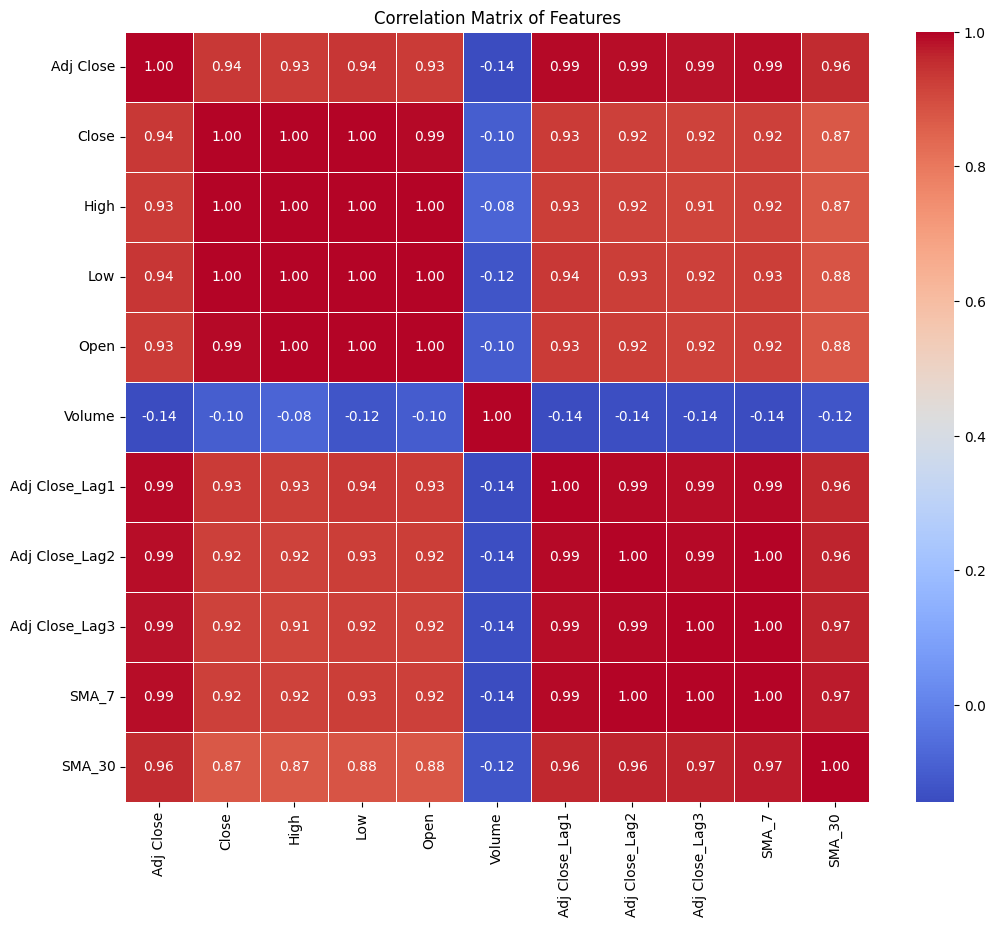

In [30]:
correlation_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Features')
plt.show()